In [1]:
import joblib
rsh = joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')
rsh.best_score_

-1.048461013941341

In [2]:
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.043552484980481455,
                          criterion='squared_error', loss='absolute_error',
                          max_depth=14, max_features=2, min_samples_split=4,
                          n_estimators=422,
                          random_state=RandomState(MT19937) at 0x2B9C5763CDB0)

In [4]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]

df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v1.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]

df_env = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env = df_env.drop(['TKN_pct'], axis=1)

df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_btm = df_env.loc[df_sites_qc_btm.index.values,:]

df_env_top_pred = df_env_top.iloc[:,np.append(range(0,21), range(24,32))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_btm_pred = df_env_btm.iloc[:,np.append(range(0,21), range(24,32))]
df_env_btm_pred = df_env_btm.fillna(0.)

results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X, y = np.log(datah7.T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [21]:
all_models = {}
common_params = dict(
    n_estimators=422,
    learning_rate=0.05,
    max_depth=14,
    min_samples_split=4,
    ccp_alpha=0.043552484980481455,
    criterion='squared_error',
    max_features=2,
)
for alpha in [0.05, 0.5, 0.95]:
    gbr = GradientBoostingRegressor(loss="quantile", alpha=alpha, **common_params)
    all_models["q %1.2f" % alpha] = gbr.fit(X_train, y_train)

In [25]:
gbr_ls = GradientBoostingRegressor(loss="squared_error", **common_params,random_state=0)
all_models["mse"] = gbr_ls.fit(X_train, y_train)

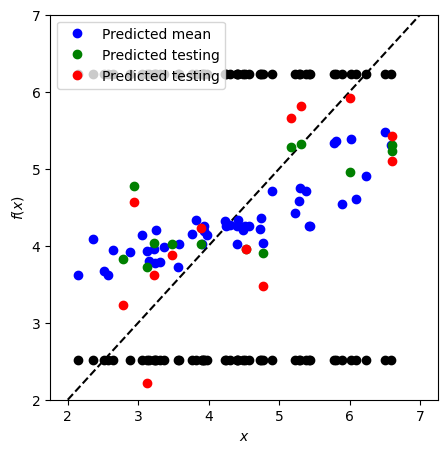

In [28]:
import matplotlib.pyplot as plt

y_pred = all_models["mse"].predict(X_train)
test_pred = all_models["mse"].predict(X_test)
test_pred2 = rsh.best_estimator_.predict(X_test)
y_lower = all_models["q 0.05"].predict(X_train)
y_upper = all_models["q 0.95"].predict(X_train)
y_med = all_models["q 0.50"].predict(X_train)

fig = plt.figure(figsize=(5, 5))
plt.plot([2, 7], [2, 7], 'k--')
#plt.plot(X_test, y_test, "b.", markersize=10, label="Test observations")
#plt.plot(y_train, y_med, "r-",  marker="o",linewidth=0,label="Predicted median")
plt.plot(y_train, y_pred, "b-",  marker="o",linewidth=0,label="Predicted mean")
plt.plot(y_test, test_pred, "g-",  marker="o",linewidth=0,label="Predicted testing")
plt.plot(y_test, test_pred2, "r-",  marker="o",linewidth=0,label="Predicted testing")
plt.plot(y_train, y_upper, "k",  marker="o",linewidth=0)
plt.plot(y_train, y_lower, "k",  marker="o",linewidth=0)
#plt.fill_between(    X_train.ravel(), y_lower, y_upper, alpha=0.4, label="Predicted 90% interval")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.ylim(2, 7)
plt.legend(loc="upper left")
plt.show()